# ProteinGym

In [ ]:
# conda create --name proteingym_env --file environments/proteingym_env.txt -c conda-forge -c bioconda -c pytorch
# !pip install proteingym -y

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd
import src.haplosaurus as hs
import src.ESM as ESM
import src.predict_esm as ESMp
import src.utils as utils
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.proteingym as pg


## Download data

In [75]:
resources_df = pg.get_resources_df()
pg_resources = pg.download_resources(
    resources_df.loc[resources_df['Filename'].isin(
        ['clinical_ProteinGym_substitutions.zip', 
         'clinical_ProteinGym_indels.zip']
        )],
    error=False)
pg.count_resources(pg_resources)

Gathering resources: 100%|██████████| 2/2 [00:08<00:00,  4.27s/it]


{'clinical_ProteinGym_substitutions': '2525 file(s)',
 'clinical_ProteinGym_indels': '1555 file(s)'}

In [2]:
proteins_df = pg.merge_resources()
proteins_df

Gathering resources: 100%|██████████| 2/2 [00:09<00:00,  4.81s/it]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id
0,NP_000933.1,NP_000933,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000933.1
1,NP_057062.1,NP_057062,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_057062.1
2,NP_002461.2,NP_002461,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_002461.2
3,NP_009005.1,NP_009005,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009005.1
4,NP_001010867.1,NP_001010867,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001010867.1
...,...,...,...,...,...
4075,NP_659403.4,NP_659403,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_659403.4
4076,UPI000059D6C5,UPI000059D6C5,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI000059D6C5
4077,NP_000742.1,NP_000742,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000742.1
4078,UPI0001533DAA,UPI0001533DAA,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0001533DAA


## Count variants

In [77]:
def get_variant_ratios(df,
                       protein_col='protein',
                       score_col='DMS_bin_score',
                       mutant_col='mutant',
                       fill_value=0):
    df = df.copy()
    # drop rows that are all NaN
    df = df.dropna(axis=1, how='all')
    print("Proteins:",df[protein_col].nunique())
    df2 = df.groupby([protein_col, score_col])[mutant_col].count().unstack(fill_value=fill_value)
    df2['total'] = df2['Benign'] + df2['Pathogenic'] 

    print('Pathogenic:',sum(df2['Pathogenic']))
    print('Benign:',sum(df2['Benign']))
    print('Pathogenic/Benign:',sum(df2['Pathogenic']) / sum(df2['Benign']))
    df2['pathogenic_ratio'] = (df2['Pathogenic']) / (df2['total'] + 1e-6)
    df2.sort_values('pathogenic_ratio', ascending=False, inplace=True)
    df2.hist('pathogenic_ratio', bins=100) 
    return df2

### Substitutions

In [7]:
clinical_subs_df = pg.concat_csvs(
    pg_resources, 
    key='clinical_ProteinGym_substitutions',
    )

Reading files in clinical_ProteinGym_substitutions: 100%|██████████| 2525/2525 [00:47<00:00, 53.35it/s]


Proteins: 2525
Pathogenic: 32000
Benign: 30727
Pathogenic/Benign: 1.0414293617990693


DMS_bin_score,Benign,Pathogenic,total,pathogenic_ratio
protein,,,,
NP_000268.1,2,397,399,0.994987
NP_005563.1,1,157,158,0.993671
NP_006000.2,1,149,150,0.993333
NP_835366.1,1,78,79,0.987342
NP_000153.1,2,146,148,0.986486
...,...,...,...,...
NP_109590.3,199,3,202,0.014851
NP_060798.2,133,2,135,0.014815
NP_001094383.2,79,1,80,0.012500


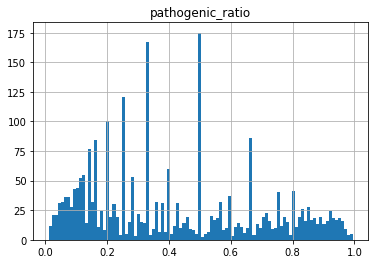

In [31]:
get_variant_ratios(clinical_subs_df)

In [21]:
# Report stats
haplotypes_per_protein = 37.5
print(clinical_subs_df['protein'].nunique()*haplotypes_per_protein,
      "haplotypes across",len(clinical_subs_df), 
      "substitutions in",clinical_subs_df['protein'].nunique(),"proteins")

sum(clinical_subs_df.groupby('mutant').size()*haplotypes_per_protein)

94687.5 haplotypes across 62727 substitutions in 2525 proteins


2352262.5

In [ ]:
# Using all benign/pathogenic variants per protein
print(sum(clinical_subs_df.groupby('protein').size()*haplotypes_per_protein))
# Using only 1 benign/pathogenic variant per protein
print(clinical_subs_df['protein'].nunique()*2*haplotypes_per_protein)

2352262.5
189375.0


### Indels

In [ ]:
clinical_indels_df = pg.concat_csvs(
    pg_resources, 
    key='clinical_ProteinGym_indels')
clinical_indels_df['protein'] = clinical_indels_df['source_file'].str.replace('.csv', '', regex=False)

Reading files in clinical_ProteinGym_indels: 100%|██████████| 1555/1555 [00:16<00:00, 95.40it/s] 


Proteins: 1555
Pathogenic: 1742
Benign: 297
Pathogenic/Benign: 5.865319865319865


DMS_score_bin,0,Benign,Pathogenic,total,pathogenic_ratio
protein,,,,,
NP_000518.1,0,0,31,31,1.0
NP_001159435.1,0,0,21,21,1.0
NP_001009944.3,0,0,18,18,1.0
NP_000129.3,0,0,16,16,1.0
NP_000240.1,0,0,14,14,1.0
...,...,...,...,...,...
UPI000013CCD8,0,0,0,0,0.0
UPI000013CCDF,0,0,0,0,0.0
UPI000013CD7C,0,0,0,0,0.0


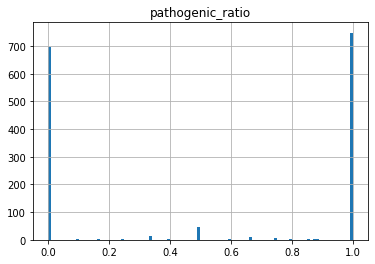

In [48]:
get_variant_ratios(clinical_indels_df,
                    score_col='DMS_score_bin',
                    mutant_col='VariationID')

In [14]:
# Report stats
haplotypes_per_protein = 37.5
print(clinical_indels_df['refseq_unique_id'].nunique()*haplotypes_per_protein,
      "estimated haplotypes across",len(clinical_indels_df), 
      "substitutions in",clinical_indels_df['refseq_unique_id'].nunique(),"proteins")
print("Total estimated haplotype sequences:",
      clinical_indels_df['refseq_unique_id'].nunique()*haplotypes_per_protein)

32175.0 haplotype sequences across 2878 substitutions in 858 proteins


In [ ]:
# Using all benign/pathogenic variants per protein
print(sum(clinical_indels_df.groupby('refseq_unique_id').size()*haplotypes_per_protein))
# Using only 1 benign/pathogenic variant per protein
print(clinical_indels_df['refseq_unique_id'].nunique()*2*haplotypes_per_protein)

76462.5
64350.0


## Benchmarking

In [61]:
vp.list_models()

['esm',
 'esm1_t12_85M_UR50S',
 'esm1_t34_670M_UR100',
 'esm1_t34_670M_UR50D',
 'esm1_t34_670M_UR50S',
 'esm1_t6_43M_UR50S',
 'esm1b_t33_650M_UR50S',
 'esm1v_t33_650M_UR90S',
 'esm1v_t33_650M_UR90S_1',
 'esm1v_t33_650M_UR90S_2',
 'esm1v_t33_650M_UR90S_3',
 'esm1v_t33_650M_UR90S_4',
 'esm1v_t33_650M_UR90S_5',
 'esm2_t12_35M_UR50D',
 'esm2_t30_150M_UR50D',
 'esm2_t33_650M_UR50D',
 'esm2_t36_3B_UR50D',
 'esm2_t48_15B_UR50D',
 'esm2_t6_8M_UR50D',
 'esm_if1_gvp4_t16_142M_UR50',
 'esm_msa1_t12_100M_UR50S',
 'esm_msa1b_t12_100M_UR50S',
 'esmfold_v0',
 'esmfold_v1']

In [3]:
candidate_proteins = utils.get_candidate_proteins()
display(candidate_proteins)

,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225
4,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,ENSP00000369497,NP_000050
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000376802,NP_000286
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000155840,NP_000209


In [9]:
candidate_proteins, prot_df = gp.map_and_filter(candidate_proteins, 
                                                      proteins_df, 
                                                      input_col1="RefSeq Protein", 
                                                      input_col2="protein", 
                                                      target_namespace="ENSP")

Mapping df1 IDs to: ENSP
Running gprofiler.convert with 11 queries.
Loading ID mapping from: '/grid/koo/home/schilder/.cache/gprofiler/idmap_6b2c517cf7b042c1ac556626986109cc.csv.gz'
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_6b2c517cf7b042c1ac556626986109cc.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENSP
Mapping df2 IDs to: ENSP
Running gprofiler.convert with 3548 queries.
Loading ID mapping from: '/grid/koo/home/schilder/.cache/gprofiler/idmap_202a1088465af5b16eeac1e33d77d8d2.csv.gz'
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_202a1088465af5b16eeac1e33d77d8d2.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENSP
df1: Keeping only the first 1 row(s) per ID.
df2: Keeping only the first 1 row(s) per ID.


In [10]:
# Import haplotypes
haplotypes = hs.get_haplotypes(cache_only=True)
hap_seqs = hs.get_haplotype_seqs(haplotypes, 
                                 aligned=2, 
#                                  use_protein_ids=True,
                                 add_haplotype_names=True)

Found 530 haplotypes in: '/grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/'


Getting haplotypes:   0%|          | 0/530 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/530 [00:00<?, ?it/s]

  0%|          | 0/530 [00:00<?, ?it/s]

In [15]:
haplotypes_df, prot_df = gp.map_and_filter(list(haplotypes.keys()), 
                                                      prot_df, 
                                                      input_col2="protein", 
                                                      target_namespace="ENSP")

Mapping df1 IDs to: ENSP
Running gprofiler.convert with 530 queries.
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_727a5996538ce843e0bbb247e38d5d21.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENSP
Mapping df2 IDs to: ENSP
Running gprofiler.convert with 12 queries.
Saving ID mapping to: '/grid/koo/home/schilder/.cache/gprofiler/idmap_b3cbf0bfa93945f5dafec011bbe88175.csv.gz'
Dropping rows with NA in ['incoming', 'converted'].
Dropping all but 3 columns.
Mapping IDs to: ENSP
df1: Keeping only the first 1 row(s) per ID.
df2: Keeping only the first 1 row(s) per ID.


In [16]:
haplotypes_df

,id,ENSP,HGNC
57,ENST00000496887,ENSP00000155840,KCNQ1
74,ENST00000353147,ENSP00000259699,HFE
96,ENST00000335475,ENSP00000155840,KCNQ1
183,ENST00000155840,ENSP00000155840,KCNQ1
195,ENST00000352993,ENSP00000312236,BRCA1
...,...,...,...
5666,ENST00000455727,ENSP00000252444,LDLR
5676,ENST00000440967,ENSP00000358633,G6PD
5769,ENST00000461397,ENSP00000259699,HFE
5800,ENST00000586385,ENSP00000312236,BRCA1


In [68]:
enst_to_ensp = hs.get_haplotype_protein_ids(haplotypes)

  0%|          | 0/530 [00:00<?, ?it/s]

In [69]:
prot_df2 = vp.filter_prot_df(prot_df)
prot_df2

NameError: name 'prot_df' is not defined

In [87]:
# Map ENP IDs
hap_seqs_id_map = gp.get_id_map(ids=hs.list_haplotypes(),
                                rename_converted=True,
                                target_namespace='ENST',
                               as_dict=-1)
print(len(hap_seqs_id_map))
proteins_df['ENST_haplosaurus'] = proteins_df['ENST'].map(hap_seqs_id_map)
proteins_df['ENSP_haplosaurus'] = proteins_df['ENST_haplosaurus'].map(enst_to_ensp) 


Found 530 haplotypes in /grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/
Running gprofiler.convert with 530 queries.
6021


In [88]:
proteins_df.isna().sum()

protein                    0
RefSeq peptide ID          0
source_file                0
source_type                0
experiment_id              0
ENSP                       0
ENST                       0
REFSEQ_PEPTIDE             0
HGNC                       0
ENSP_haplosaurus     8556876
ENST_haplosaurus     8556876
dtype: int64

In [70]:
## Get a list of usable proteins

# prot_df = proteins_df.loc[proteins_df['ENSP'].isin(hap_seqs_id_all)]
prot_df = proteins_df.loc[proteins_df['ENST_haplosaurus'].notna()] 
# prot_df = proteins_df.copy()
prot_df = prot_df.loc[(prot_df['RefSeq peptide ID'].isin(candidate_proteins['RefSeq Protein Stable'].tolist())) |
                  (prot_df['REFSEQ_PEPTIDE'].isin(candidate_proteins['REFSEQ_PEPTIDE'].tolist())) |
                  (prot_df['protein'].isin(candidate_proteins['REFSEQ_PEPTIDE'].tolist())) |
                  (prot_df['ENST'].isin(candidate_proteins['ENST'].tolist())) |
                  (prot_df['ENSP'].isin(candidate_proteins['ENSP'].tolist())) |
                  (prot_df['ENST_haplosaurus'].isin(candidate_proteins['ENST'].tolist())) |
                  (prot_df['ENSP_haplosaurus'].isin(candidate_proteins['ENSP'].tolist())) |
                  (prot_df['HGNC'].isin(candidate_proteins['Gene'].tolist())) |
                  (prot_df['HGNC'].isin(candidate_proteins['HGNC'].tolist()))
                   ]
prot_df = prot_df.loc[prot_df['source_type']=='clinical_ProteinGym_substitutions']
# Only keep the first occurence of each experiment_id (to avoid artifacts of ID mapping)
prot_df = prot_df.drop_duplicates(subset=['experiment_id'])

protein_ids = prot_df['protein'].unique()
print(len(protein_ids),"unique proteins") 
prot_df  

KeyError: 'ENST_haplosaurus'

In [33]:
mut_df=  pd.read_csv("/grid/koo/home/schilder/.cache/ProteinGym/clinical_ProteinGym_substitutions/NP_000509.1.csv")
mut_df['seq_len'] = mut_df['protein_sequence'].map(len)
print((mut_df['protein_sequence'][0]))
# prot_df

MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH


In [53]:
pg.filter_prot_df(prot_df=prot_df, 
                          protein_ids=protein_ids, 
                          source_types=source_types, 
                          haplotypes=haplotypes)

,protein,RefSeq peptide ID,source_file,source_type,experiment_id
0,NP_073624.2,NP_073624,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_073624.2
1,UPI0000457614,UPI0000457614,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0000457614
2,NP_055862.1,NP_055862,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_055862.1
3,NP_775831.2,NP_775831,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_775831.2
4,NP_057122.2,NP_057122,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_057122.2
...,...,...,...,...,...
4075,UPI0000186945,UPI0000186945,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0000186945
4076,NP_071908.2,NP_071908,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_071908.2
4077,UPI00004DDD95,UPI00004DDD95,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI00004DDD95
4078,NP_000249.1,NP_000249,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000249.1


In [37]:
save_paths = vepp.vep_pipeline(models = ["esm1v_t33_650M_UR90S_1"],
                     scoring_strategies = {"esm1v_t33_650M_UR90S_1":["wt-marginals", "masked-marginals"]},
                     protein_ids = ["NP_000509.1"],
                     source_types = ["clinical_ProteinGym_substitutions"],
                     )
save_paths

Running gprofiler.convert with 3548 queries.
Running gprofiler.convert with 3548 queries.
Running gprofiler.convert with 3548 queries.
`haplotypes` not provided. Importing haplotype sequences from '/grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/'
Found 530 haplotypes in: '/grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/'


Getting haplotypes:   0%|          | 0/530 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/530 [00:00<?, ?it/s]

  0%|          | 0/530 [00:00<?, ?it/s]

Running gprofiler.convert with 530 queries.


...

Processing scoring strategies:   0%|          | 0/2 [00:00<?, ?it/s]

/grid/koo/home/schilder/.local/lib/python3.9/site-packages/esm/pretrained.py:215: UserWarning: Regression weights not found, predicting contacts will not produce correct results.
  warnings.warn(


Transferred model to GPU





Computing 'wt-marginals' for esm1v_t33_650M_UR90S_1:   2%|▏         | 1/61 [00:00<00:00, 935.18it/s]


ValueError: No matching sequence found at position 146 for reference: 'MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRVSLWDA*'

In [31]:
len('MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH')
len('MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRVSLWDA*')

112

In [ ]:

# Script to generate mutational landscape
# predict_esm.py script from: https://github.com/facebookresearch/esm/blob/main/examples/variant-prediction/predict.py
import os
from tqdm.auto import tqdm
save_dir = '/grid/koo/home/schilder/projects/data/1KG/vep/'
force = False
verbose = True

## Folder stucture
# {save_dir}/
#   {model}/
#     {protein_id}/
#       {haplotypes}/
#         {source_type}/
#           {scoring_strategy}.csv.gz


# Scoring strategy
scoring_strategy = ["wt-marginals", "masked-marginals", "pseudo-ppl"]
if isinstance(scoring_strategy, str):
    scoring_strategy = [scoring_strategy]
    
if "pseudo-ppl" in scoring_strategy:
    print("Warning: scoring_strategy='pseudo-ppl' can take significant compute for large protein sequences, as it considers the entire sequence at once.")

# Model location
model_location = "esm1v_t33_650M_UR90S_1"

save_paths = {}
# Iterate over proteins
for pid in tqdm(protein_ids[:10], desc="Processing proteins"):
    
    prot_df_i = prot_df.loc[prot_df['protein']==pid]
    
    # Map protein id to ensp_id
    enst_id = prot_df_i['ENST_haplosaurus'].tolist()[0]
    assert len(enst_id)>0
    ensp_id = prot_df_i['ENSP_haplosaurus'].tolist()[0]
    assert len(ensp_id)>0

    # Iterate over variant types (eg. substitutions, indels)
    for _, row in prot_df_i.iterrows():

        # Get path to variant file
        variants_path = row['source_file']
        variants_type = row['source_type']
        assert os.path.exists(variants_path)

        # Get reference sequence
        # ref_seq_name, ref_seq = hs.get_haplotype_ref(hap_seqs[ensp_id])[0]

        # Iterate over haplotypes
        for seq_name, seqs in tqdm(hap_seqs[enst_id], 
                                  desc="Processing haplotypes", 
                                  leave=False):
            is_ref = seq_name.endswith('REF')
            # Summarise really long seq_name
            if seq_name.count(",")>10: # More than 10 mutations
                seq_name_save = utils.encode_haplotype_name(seq_name)
            else:
                seq_name_save = seq_name
                
            # ESM1b/v models cannot handle sequnces longer than 1024 
            # https://github.com/facebookresearch/esm/issues/166
            seq_len = len(ESMp.preprocess_sequence(seqs[1]))
            if (model_location.startswith('esm1v') or model_location.startswith('esm1b')) and seq_len > 1024:
                if verbose:
                    print(f"Skipping {pid} {seq_name} because sequence is too long for model '{model_location}' ({seq_len} > 1024)")
                continue
            
            # Conver to MultipleSequenceAlignment so we can inject mutations at the correct positions
            msa = utils.as_msa(seqs) 
            
            # Iterate over scoring strategies
            for ss in tqdm(scoring_strategy,
                           desc="Processing scoring strategies",
                           leave=False): 
                # create save path
                save_path = os.path.join(save_dir, 
                                        model_location, 
                                        pid, 
                                        seq_name_save,
                                        variants_type,
                                        f"{ss}.csv.gz")
                save_paths[(pid, seq_name, ss)] = save_path
                if os.path.exists(save_path) and not force:
                    continue
                else:
                    os.makedirs(os.path.dirname(save_path), exist_ok=True)
                # Run script via command line
                ESMp.main(
                    dms_input=variants_path,
                    dms_output=save_path,
                    model_location=[model_location],
                    sequence=msa,
                    mutation_col="mutant",
                    offset_idx=1,
                    scoring_strategy=ss,
                    is_ref=is_ref, 
                    force=False
                )

Processing proteins:   0%|          | 0/8 [00:00<?, ?it/s]

Processing haplotypes:   0%|          | 0/15 [00:00<?, ?it/s]

Processing scoring strategies:   0%|          | 0/3 [00:00<?, ?it/s]

/grid/koo/home/schilder/.local/lib/python3.9/site-packages/esm/pretrained.py:215: UserWarning: Regression weights not found, predicting contacts will not produce correct results.
  warnings.warn(


Transferred model to GPU
Transferred model to GPU


...

/grid/koo/home/schilder/.local/lib/python3.9/site-packages/esm/pretrained.py:215: UserWarning: Regression weights not found, predicting contacts will not produce correct results.
  warnings.warn(


Transferred model to GPU
Transferred model to GPU





  0%|          | 0/149 [00:00<?, ?it/s]


  2%|▏         | 3/149 [00:00<00:07, 19.79it/s]


  3%|▎         | 5/149 [00:00<00:08, 17.86it/s]


  5%|▍         | 7/149 [00:00<00:08, 16.75it/s]


  6%|▌         | 9/149 [00:00<00:08, 16.47it/s]


  7%|▋         | 11/149 [00:00<00:08, 16.04it/s]


  9%|▊         | 13/149 [00:00<00:08, 15.82it/s]


 10%|█         | 15/149 [00:00<00:08, 15.90it/s]


 11%|█▏        | 17/149 [00:01<00:08, 15.73it/s]


 13%|█▎        | 19/149 [00:01<00:08, 15.70it/s]


 14%|█▍        | 21/149 [00:01<00:08, 15.57it/s]


 15%|█▌        | 23/149 [00:01<00:08, 15.73it/s]


 17%|█▋        | 25/149 [00:01<00:07, 15.62it/s]


 18%|█▊        | 27/149 [00:01<00:07, 15.53it/s]


 19%|█▉        | 29/149 [00:01<00:07, 15.73it/s]


 21%|██        | 31/149 [00:01<00:07, 15.61it/s]


 22%|██▏       | 33/149 [00:02<00:07, 15.74it/s]


 23%|██▎       | 35/149 [00:02<00:07, 15.62it/s]


 25%|██▍       | 37/149 [00:02<00:07, 15.74it/s]


 26%|██▌       | 39/149 [00:02<00:07, 15.

Transferred model to GPU





Computing 'pseudo-ppl' for esm1v_t33_650M_UR90S_1:   0%|          | 0/61 [00:00<?, ?it/s]

In [23]:
# Merge the files
vep_df = ESM.merge_vep(save_dir)
vep_df


Found 15 pseudo-ppl files


Reading files: 100%|██████████| 15/15 [00:00<00:00, 45.35it/s]


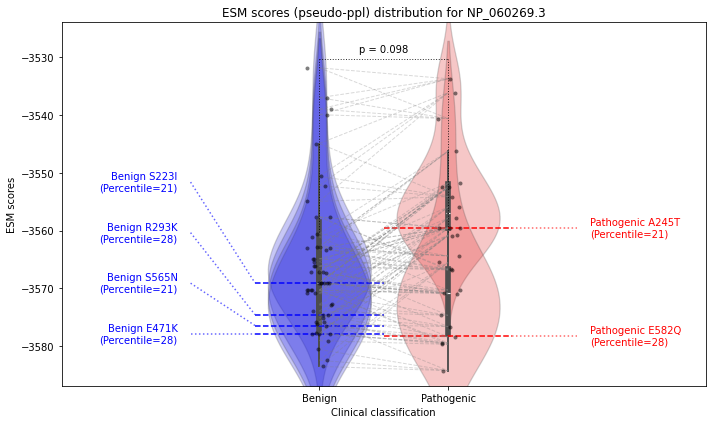

In [26]:

ESM.plot_vep_violin(vep_df, 
                    model_location="esm1v_t33_650M_UR90S_1")